In [3]:
!ls

'brain_tumor_dataset (1) (1).zip'   dataset	  test.jpg
'brain_tumor_dataset (1).zip'	    sample_data


Saving brain_tumor_dataset.zip to brain_tumor_dataset (5).zip
Archive:  brain_tumor_dataset.zip
  inflating: no/1 no.jpeg            
  inflating: no/10 no.jpg            
  inflating: no/11 no.jpg            
  inflating: no/12 no.jpg            
  inflating: no/13 no.jpg            
  inflating: no/14 no.jpg            
  inflating: no/15 no.jpg            
  inflating: no/17 no.jpg            
  inflating: no/18 no.jpg            
  inflating: no/19 no.jpg            
  inflating: no/2 no.jpeg            
  inflating: no/20 no.jpg            
  inflating: no/21 no.jpg            
  inflating: no/22 no.jpg            
  inflating: no/23 no.jpg            
  inflating: no/24 no.jpg            
  inflating: no/25 no.jpg            
  inflating: no/26 no.jpg            
  inflating: no/27 no.jpg            
  inflating: no/28 no.jpg            
  inflating: no/29 no.jpg            
  inflating: no/3 no.jpg             
  inflating: no/30 no.jpg            
  inflating: no/31 no.jpg     

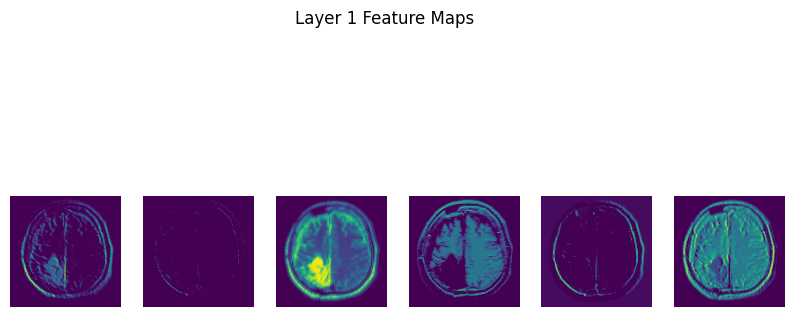

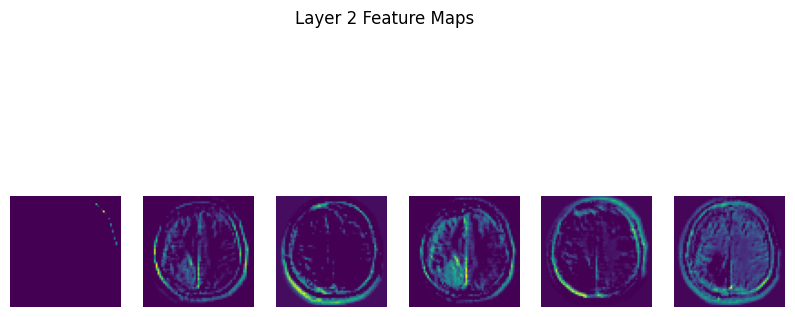

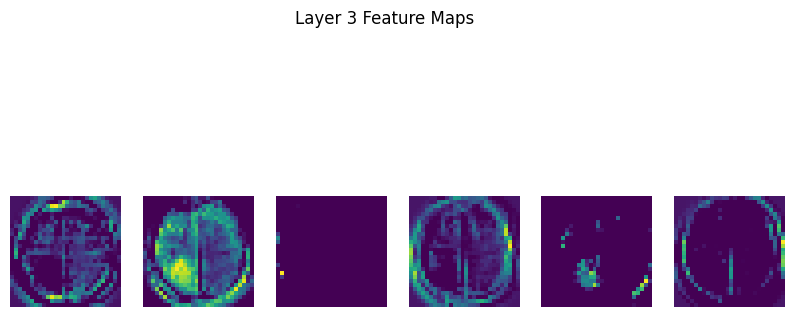

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
Tumor Detected
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Using layer: conv2d_17


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_79']
Received: inputs=Tensor(shape=(1, 128, 128, 3))
  warnings.warn(msg)


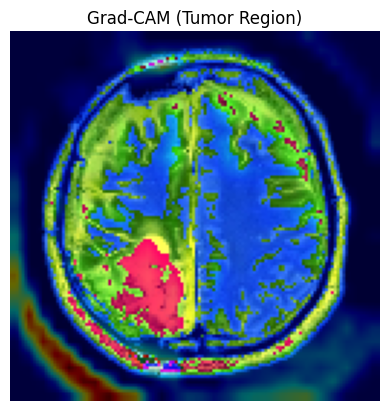

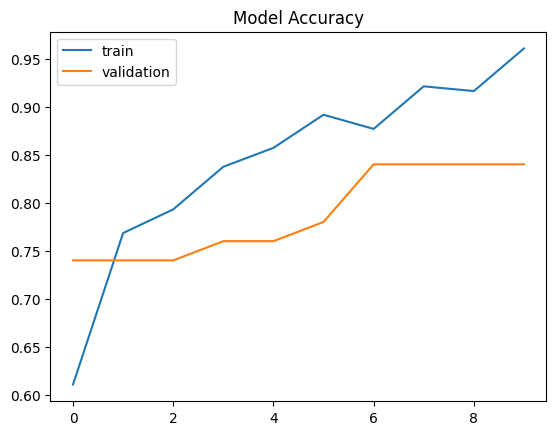

In [8]:
from google.colab import files
uploaded = files.upload()
! unzip -o brain_tumor_dataset.zip
!mkdir dataset
!mv yes dataset/
!mv no dataset/
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

dataset_path = "/content/dataset"

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)
print("Training samples:", train_data.samples)
print("Validation samples:", val_data.samples)
print("Classes:", train_data.class_indices)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128,activation='relu'),
    Dense(1,activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_data,
    epochs=10,
    validation_data=val_data
)

loss, accuracy = model.evaluate(val_data)
print("Validation Accuracy:", accuracy)

from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model

# Load image
img_path = "/content/test.jpg"

img = image.load_img(img_path, target_size=(128,128))
img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

# Get conv layer outputs
layer_outputs = [layer.output for layer in model.layers if 'conv' in layer.name]

# FIXED LINE
activation_model = Model(inputs=model.inputs, outputs=layer_outputs)

activations = activation_model.predict(img_array)


for i, activation in enumerate(activations):
    plt.figure(figsize=(10,5))

    for j in range(min(6, activation.shape[-1])):
        plt.subplot(1,6,j+1)
        plt.imshow(activation[0,:,:,j], cmap='viridis')
        plt.axis('off')

    plt.suptitle(f"Layer {i+1} Feature Maps")
    plt.show()
img = image.load_img("/content/test.jpg", target_size=(128,128))
img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

if prediction[0] > 0.5:
    print("Tumor Detected")
else:
    print("No Tumor")
import tensorflow as tf
import cv2
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Model
import tensorflow as tf
import numpy as np

def get_gradcam(model, img_array, last_conv_layer_name):


    last_conv_layer = model.get_layer(last_conv_layer_name)

    conv_model = tf.keras.Model(
        inputs=model.inputs,
        outputs=last_conv_layer.output
    )

    classifier_input = tf.keras.Input(shape=last_conv_layer.output.shape[1:])

    x = classifier_input
    for layer in model.layers[model.layers.index(last_conv_layer)+1:]:
        x = layer(x)

    classifier_model = tf.keras.Model(classifier_input, x)

    with tf.GradientTape() as tape:
        conv_outputs = conv_model(img_array)
        tape.watch(conv_outputs)

        predictions = classifier_model(conv_outputs)
        class_idx = tf.argmax(predictions[0])
        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.reduce_max(heatmap)

    return heatmap.numpy()
img_path = "/content/test.jpg"

img = image.load_img(img_path, target_size=(128,128))
img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)
_ = model.predict(img_array)
last_conv_layer_name = None

for layer in reversed(model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer_name = layer.name
        break

print("Using layer:", last_conv_layer_name)

heatmap = get_gradcam(model, img_array, last_conv_layer_name)
img = cv2.imread(img_path)
img = cv2.resize(img, (128,128))

heatmap = cv2.resize(heatmap, (128,128))
heatmap = np.uint8(255 * heatmap)

heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

superimposed_img = heatmap * 0.4 + img

plt.imshow(cv2.cvtColor(superimposed_img.astype('uint8'), cv2.COLOR_BGR2RGB))
plt.title("Grad-CAM (Tumor Region)")
plt.axis('off')
plt.show()
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='validation')

plt.title("Model Accuracy")
plt.legend()
plt.show()